## NGL vinth2p
[vinth2p documentation](https://www.pyngl.ucar.edu/Functions/Ngl.vinth2p.shtml)

In [18]:
import Ngl
import os
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from xarray.coders import CFDatetimeCoder
from matplotlib.dates import DateFormatter, HourLocator, date2num, num2date
from matplotlib.colors import BoundaryNorm

SCRATCHDIR = "/glade/derecho/scratch/nforcone"
RUNDIR = "CAM_6_4_025_20240829_SEne30_DefaultLev_fadiab_lamb_isothermal_275K/run"
FILENAME = "CAM_6_4_025_20240829_SEne30_DefaultLev_fadiab_lamb_isothermal_275K.cam.h0i.0001-01-01-01800.nc"
joined_path = os.path.join(SCRATCHDIR, RUNDIR, FILENAME)
joined_path
ds = xr.open_dataset(joined_path, decode_cf=False)
time_dt = num2date(ds["time"])

In [19]:
levels = np.linspace(-0.5, 0.5, num=11)
levels

array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5])

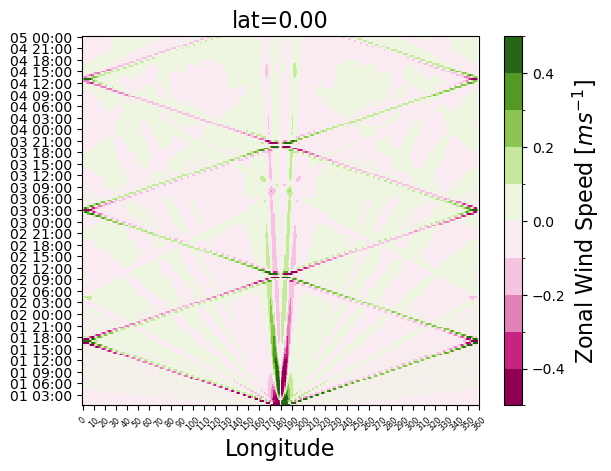

In [25]:
def Hovmoller(MyAx, field_DataArray, lat_val, MyCMAP, MyNorm):
    labelsize = 16
    times = field_DataArray.time
    lons = field_DataArray.lon

    field = field_DataArray[:,:, :].sel(lat=lat_val, method="nearest")

    CF = MyAx.pcolormesh(lons, times, field, cmap=MyCMAP, norm=MyNorm)
    cb = plt.colorbar(CF, ax=MyAx)
    cb.set_label(r'Zonal Wind Speed [$m s^{-1}$]', size=labelsize)
    # MyAx.set_xticks([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360])
    plt.xticks(rotation=45, size='xx-small')
    MyAx.set_xticks(np.arange(0, 361, step=10))
    MyAx.set_xlabel("Longitude", size=labelsize)
    MyAx.yaxis.set_major_locator(HourLocator(interval=3))
    MyAx.yaxis.set_major_formatter(DateFormatter("%d %H:%M"))
    MyAx.set_title(f"lat={field.lat:.2f}", size=labelsize)


# figure and axes
plt.figure(1)
hovmoller_ax = plt.axes()

# parameters
lat_value = 0
cmap = plt.colormaps['PiYG']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

Hovmoller(hovmoller_ax, ds.U850, lat_value, cmap, norm)
# plt.savefig('U-Hovmoller-plev-850-More-Ticks.png', dpi=250)

In [26]:
ds

<xarray.Dataset> Size: 9GB
Dimensions:       (lat: 181, lon: 360, lev: 30, ilev: 31, trop_pref: 30,
                   trop_prefi: 31, time: 192, nbnd: 2, chars: 8)
Coordinates:
  * lat           (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 88.0 89.0 90.0
  * lon           (lon) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * lev           (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * trop_pref     (trop_pref) float64 240B 3.643 7.595 14.36 ... 976.3 992.6
  * trop_prefi    (trop_prefi) float64 248B 2.255 5.032 10.16 ... 985.1 1e+03
  * time          (time) float64 2kB 0.02083 0.04167 0.0625 ... 3.958 3.979 4.0
Dimensions without coordinates: nbnd, chars
Data variables: (12/49)
    w             (lat) float64 1kB ...
    hyam          (lev) float64 240B ...
    hybm          (lev) float64 240B ...
    hyai          (ilev) float64 248B ...
    hybi          (ilev) float64 248B ...
    date          (time) int32 768B ...
    ...            ...
    Z700          (time, lat, lon) float32 50MB ...
    T             (time, lev, lat, lon) float32 2GB ...
    U             (time, lev, lat, lon) float32 2GB ...
    V             (time, lev, lat, lon) float32 2GB ...
    Z3            (time, lev, lat, lon) float32 2GB ...
    OMEGA         (time, lev, lat, lon) float32 2GB ...
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              CAM_6_4_025_20240829_SEne30_DefaultLev_fadiab_lamb_iso...
    logname:           nforcone
    host:              dec2360
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
    topography_file:   bnd_topo
    model_doi_url:     not_set
    time_period_freq:  minute_30

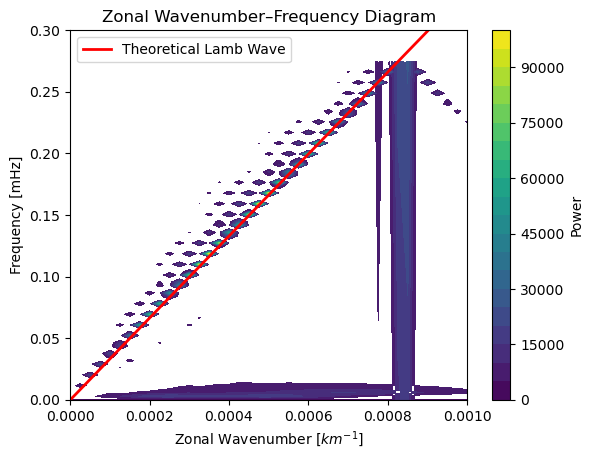

In [87]:
from scipy.fft import rfft2, fftfreq, rfftfreq

x = ds.U850.sel(lat=0)
x_anom = x - x.mean(dim='time')
x_fft = rfft2(x_anom)
nt, nx = x_anom.shape
dt = 1800  # output timestep (seconds)
dx = 111*1000  # horizontal grid spacing at the equator in meters
freq = fftfreq(nt, d=dt)
wavenumber = rfftfreq(nx, d=dx) * 1e3  # km^-1
power = np.abs(x_fft)**2

# cs
T0 = 275
Rd = 287
cp = 1004
cv = 717
gamma = cp / cv
cs = np.sqrt(gamma * Rd * T0) / 1000  # km s^-1
omega = cs * wavenumber * 1e3

# Plot
plt.figure(2)
plt.contourf(wavenumber, freq*1e3, power, levels=20)
plt.plot(wavenumber, omega, 'r-', label='Theoretical Lamb Wave', linewidth=2)
plt.xlabel(r"Zonal Wavenumber [$km^{-1}$]")
plt.ylabel("Frequency [mHz]")
plt.xlim((0, 0.001))
plt.ylim((0, 0.3))
plt.title("Zonal Wavenumber–Frequency Diagram")
plt.colorbar(label='Power')
plt.legend()
plt.show()

In [90]:
H = (Rd*T0) / 9.81
z_top = -H * np.log(3.643466 / 100000)
z_top

82223.51822571922

In [91]:
# extract variables (need numpy arrays for vertical interpolation)
hyam = ds["hyam"].to_numpy()
hybm = ds["hybm"].to_numpy()
U    = ds["U"].to_numpy()   # [time: 240, lev: 30, lat: 257, lon: 512]
psrf = ds["PS"].to_numpy()  # [time: 240, lat: 257, lon: 512] MUST BE Pa
p0   = 1000                 # MUST BE hPa
lats = ds["lat"].to_numpy()
lons = ds["lon"].to_numpy()

# define the output pressure levels.
pnew = np.array([976, 936, 887, 820, 691, 610, 524, 446, 322, 232, 143, 88, 25])  # MUST BE hPa

# interpolation settings
intyp = 1      # 1=linear, 2=log, 3=log-log
kxtrp = False  # True=extrapolate (when the output pressure level is outside of the range of psrf)

# vertical interpolation
U_interp = Ngl.vinth2p(U, hyam, hybm, pnew, psrf, intyp, p0, 1, kxtrp)
U_interp[U_interp==1e30] = np.nan

# create new xarray DataArray
coords_dict = {'time': time_dt,
               'plev': pnew,
               'lat': lats,
               'lon': lons}

dim_names = ['time', 'plev', 'lat', 'lon']
U_interp_da = xr.DataArray(U_interp, dims=dim_names, coords=coords_dict)
U_interp_da

<xarray.DataArray (time: 192, plev: 13, lat: 181, lon: 360)> Size: 1GB
array([[[[-3.94433269e-13, -3.94433269e-13, -3.94433269e-13, ...,
          -3.94433269e-13, -3.94433269e-13, -3.94433269e-13],
         [-3.84780829e-13, -3.76137489e-13, -3.67447751e-13, ...,
          -3.96657975e-13, -3.92946601e-13, -3.88988474e-13],
         [-3.79697526e-13, -3.78070259e-13, -3.76343112e-13, ...,
          -3.67621329e-13, -3.71677477e-13, -3.75709940e-13],
         ...,
         [-3.88785557e-13, -3.85102278e-13, -3.81537408e-13, ...,
          -3.62145237e-13, -3.71083616e-13, -3.79967185e-13],
         [-4.06736936e-13, -4.03784835e-13, -4.00801128e-13, ...,
          -3.91931515e-13, -3.97104480e-13, -4.02041039e-13],
         [-3.94433296e-13, -3.94433296e-13, -3.94433296e-13, ...,
          -3.94433296e-13, -3.94433296e-13, -3.94433296e-13]],

        [[-2.62974540e-13, -2.62974540e-13, -2.62974540e-13, ...,
          -2.62974540e-13, -2.62974540e-13, -2.62974540e-13],
         [-3.53458398e-13, -3.44314365e-13, -3.35208987e-13, ...,
          -3.72314467e-13, -3.66193629e-13, -3.59908575e-13],
         [-3.13787099e-13, -3.10528863e-13, -3.07182688e-13, ...,
          -3.02733999e-13, -3.06564424e-13, -3.10259422e-13],
...
         [-2.93196219e-11,  1.97993874e-05,  3.95297541e-05, ...,
          -5.91297215e-05, -3.95298120e-05, -1.97994456e-05],
         [-2.99417028e-11, -1.03896269e-05, -2.08042918e-05, ...,
           3.12681559e-05,  2.08042318e-05,  1.03895670e-05],
         [-3.04847756e-11, -3.04847756e-11, -3.04847756e-11, ...,
          -3.04847756e-11, -3.04847756e-11, -3.04847756e-11]],

        [[-3.63050139e-11, -3.63050139e-11, -3.63050139e-11, ...,
          -3.63050139e-11, -3.63050139e-11, -3.63050139e-11],
         [-3.72170560e-11, -4.32972731e-04, -8.65806519e-04, ...,
           1.29835974e-03,  8.65806461e-04,  4.32972672e-04],
         [-3.81312122e-11, -4.43358239e-04, -8.86576007e-04, ...,
           1.32949902e-03,  8.86575948e-04,  4.43358152e-04],
         ...,
         [-3.48825139e-11, -4.43358239e-04, -8.86576007e-04, ...,
           1.32949914e-03,  8.86575948e-04,  4.43358152e-04],
         [-3.57869224e-11, -4.32972731e-04, -8.65806520e-04, ...,
           1.29835974e-03,  8.65806461e-04,  4.32972672e-04],
         [-3.67684249e-11, -3.67684249e-11, -3.67684249e-11, ...,
          -3.67684249e-11, -3.67684249e-11, -3.67684249e-11]]]])
Coordinates:
  * time     (time) object 2kB 1970-01-01T00:30:00+00:00 ... 1970-01-05T00:00...
  * plev     (plev) int64 104B 976 936 887 820 691 610 524 446 322 232 143 88 25
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0

Text(0.5, 1.0, '02:00')

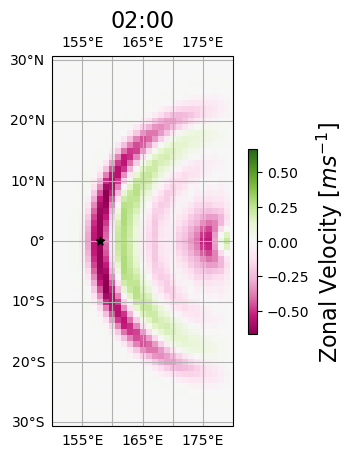

In [134]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mticker

Full_time_ind = 3

FullFig = plt.figure(3)
FullAx = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
Full_CF = FullAx.pcolormesh(U_interp_da.lon, U_interp_da.lat, U_interp_da[Full_time_ind, :, :, :].sel(plev=850, method="nearest"), 
                            transform=ccrs.PlateCarree(), cmap='PiYG')
Full_cb = FullFig.colorbar(Full_CF, ax=FullAx, shrink=0.5, pad=0.03)
Full_cb.set_label(r'Zonal Velocity [$m s^{-1}$]', size=16)
Full_gl = FullAx.gridlines(draw_labels=True)
Full_gl.xlines = True
Full_gl.ylines = True
Full_gl.right_labels = False
Full_gl.xlocator = mticker.FixedLocator(np.arange(150, 181, step=5))
FullAx.set_extent([150, 180, -30, 30])
FullAx.scatter(158, 0, marker='*', transform=ccrs.PlateCarree(), color='black', zorder=2)
FullAx.set_title(f'{time_dt[Full_time_ind].strftime("%H:%M")}', size=16)

In [112]:
U_interp_da[Full_time_ind, :, :, :].sel(plev=850, lat=0, lon=158, method="nearest")

<xarray.DataArray ()> Size: 8B
array(-0.64102261)
Coordinates:
    time     datetime64[ns] 8B 1970-01-01T02:00:00
    plev     int64 8B 820
    lat      float64 8B 0.0
    lon      float64 8B 158.0

Text(0.5, 0, 'Pressure [hPa]')

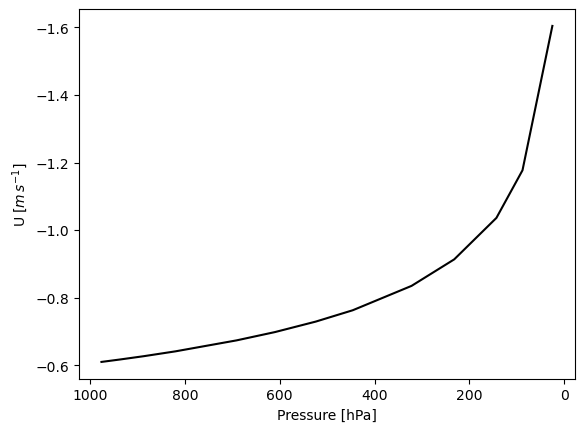

In [124]:
plt.figure(4)
num4 = plt.axes(projection=None)
num4.plot(U_interp_da.plev, U_interp_da[Full_time_ind, :, :, :].sel(lat=0, lon=158, method="nearest"), color='black')
num4.invert_xaxis()
num4.invert_yaxis()
num4.set_ylabel(r'U [$m\,s^{-1}$]')
num4.set_xlabel('Pressure [hPa]')